<a href="https://colab.research.google.com/github/ianbounos/Sistemas-Din-micos-e-IA-aplicados-al-modelado-de-datos/blob/main/Data_Augmentation_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de imágenes con Fashion MNIST

Este notebook utiliza el dataset **Fashion MNIST** para entrenar una red neuronal simple que clasifica imágenes de ropa en 10 categorías (remeras, pantalones, zapatos, etc.).

## Objetivo

Evaluar cómo la **aumentación de datos (data augmentation)** impacta en el rendimiento del modelo. Vamos a comparar dos enfoques:

1. Entrenamiento **sin aumentación** (modelo base).
2. Entrenamiento **con datos aumentados** utilizando `ImageDataGenerator`.

Fashion MNIST contiene **60,000 imágenes de entrenamiento** y **10,000 imágenes de prueba**, cada una de 28×28 píxeles en escala de grises.

## ¿Qué es la aumentación de datos?

Es una técnica que genera nuevas versiones de las imágenes originales aplicando transformaciones como rotaciones, zooms y traslaciones. Esto permite que el modelo generalice mejor y sea más robusto a pequeñas variaciones.

In [3]:
# Imports de utilidades de Python
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

# Imports de Keras
from keras.datasets import mnist,fashion_mnist
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, Activation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
#from keras.utils import np_utils, plot_model
from keras.regularizers import l1

# Hacer que TensorFlow no imprima ningún mensaje en consola
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'

from tensorflow.keras.preprocessing.image import ImageDataGenerator


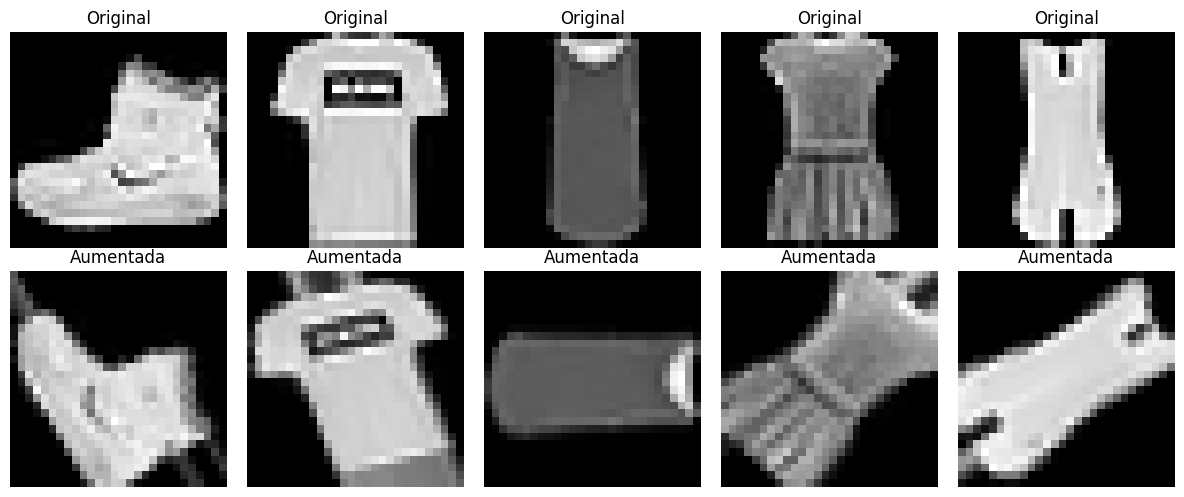

In [6]:
(X_train_raw, y_train), (X_test_raw, y_test) = fashion_mnist.load_data()

categories = ['T-shirt/top', 'Trouser','Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Reshape para que tengan canal (requerido por ImageDataGenerator)
X_train = X_train_raw.reshape((-1, 28, 28, 1))
X_test = X_test_raw.reshape((-1, 28, 28, 1))

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# Crear un generador con rotación y zoom
datagen = ImageDataGenerator(
    rotation_range=100,      # Rotación aleatoria entre esos angulos
    zoom_range=0.2,         # Zoom aleatorio entre [1-0.2, 1+0.2] = [0.8, 1.2]
    fill_mode='nearest'     # Cómo rellenar los bordes al rotar/zoomear
)

# Elegimos algunas imágenes para ver qué hace el generador
sample_images = X_train[:5]

# Aplicar aumentación y mostrar ejemplos
augmented_iter = datagen.flow(sample_images, batch_size=5, shuffle=False)

augmented_images = next(augmented_iter)

# Mostrar imágenes originales y aumentadas
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(5):
    axes[0, i].imshow(sample_images[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title("Original")

    axes[1, i].imshow(augmented_images[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("Aumentada")

plt.tight_layout()
plt.show()

# ¿El modelo simple seguirá clasificando bien si lo testeo sobre imagenes rotadas?

In [7]:
# construir el vector de entrada a partir de los 28x28 píxeles
X_train_raw = X_train_raw.reshape(60000, 784)
X_test_raw = X_test_raw.reshape(10000, 784)
X_train_raw = X_train_raw.astype('float32')
X_test_raw = X_test_raw.astype('float32')

# Normalizar los datos para ayudar con el entrenamiento
X_train = X_train_raw/255.0
X_test = X_test_raw/255.0

# Imprimir las dimensiones de entrada para el entrenamiento
print("Train matrix shape", X_train.shape)
print("Test matrix shape", X_test.shape)

values,counts = np.unique(y_train, return_counts=True)
print("Values:", values)
print("Counts:", counts)

# Importar to_categorical de tensorflow.keras.utils
from tensorflow.keras.utils import to_categorical

# one-hot encoding using keras' numpy-related utilities
n_classes = 10
print("Shape of y_train [before one-hot encoding]: ", y_train.shape)

# Generamos las nuevas variables que vamos a usar como etiquetas obejtivo
Y_train = to_categorical(y_train, n_classes) # Use to_categorical directly
Y_test = to_categorical(y_test, n_classes) # Use to_categorical directly
print("Shape of Y_train [after one-hot encoding]: ", Y_train.shape)

# Definimos el modelo secuencial (primero esta vacio)
model_simple = Sequential()

# Agregamos una capa, con activación softmnax
model_simple.add(Dense(10,activation='softmax'))

model_simple.compile(loss='categorical_crossentropy', metrics=['categorical_accuracy'], optimizer='adam')

history = model_simple.fit(X_train, Y_train,
          batch_size=32, epochs=10,
          verbose=1,
          validation_data=(X_test, Y_test))

salida = model_simple.predict(X_test[0:1])

print('Shape de la salida:',salida.shape)
print('Salida:',salida)

ertiqueta_prediccion = salida[0].argmax()
etiquta_real = y_test[0]

print('Calse asignada por la red:', ertiqueta_prediccion)
print('Calse real:', etiquta_real)
# Usamos el modelo para predecir sobre todas las instancias en ambos sets
y_train_pred = model_simple.predict(X_train)
y_test_pred = model_simple.predict(X_test)

# Tomamos como clase predicha aquella con mayor probabilidad
train_accuracy =  metrics.accuracy_score(y_train_pred.argmax(axis=1),y_train)
test_accuracy =  metrics.accuracy_score(y_test_pred.argmax(axis=1), y_test)

print('Accuracy en el train set:', train_accuracy)
print('Accuracy en el test set:', test_accuracy)



Train matrix shape (60000, 784)
Test matrix shape (10000, 784)
Values: [0 1 2 3 4 5 6 7 8 9]
Counts: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]
Shape of y_train [before one-hot encoding]:  (60000,)
Shape of Y_train [after one-hot encoding]:  (60000, 10)
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - categorical_accuracy: 0.7338 - loss: 0.7784 - val_categorical_accuracy: 0.8252 - val_loss: 0.5110
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - categorical_accuracy: 0.8414 - loss: 0.4690 - val_categorical_accuracy: 0.8311 - val_loss: 0.4824
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - categorical_accuracy: 0.8500 - loss: 0.4349 - val_categorical_accuracy: 0.8357 - val_loss: 0.4729
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - categorical_accuracy: 0.8529 - loss: 0.4286 - val_categorical_accuracy: 0.8424 - val_loss: 0.4623
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - categorical_accuracy: 0.8600 - loss: 0.4122 - val_categorical_a

In [14]:
# Primero: reshape y normalización como hiciste
X_test_aug = X_test_raw.reshape((-1, 28, 28, 1)).astype('float32') / 255.0

# Creamos un generador para test (sin shuffle para mantener el orden)
datagen_test = ImageDataGenerator(
    rotation_range=100,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Generamos una versión aumentada del test completo
# Tené en cuenta que esto genera imágenes "nuevas", pero no hay aumento infinito
X_test_augmented = next(datagen_test.flow(X_test_aug, batch_size=10000, shuffle=False))

# Las convertimos al mismo formato del modelo (flatten)
X_test_aug_flat = X_test_augmented.reshape((10000, 784))

# Evaluamos el modelo entrenado sobre estas nuevas imágenes
loss, accuracy = model_simple.evaluate(X_test_aug_flat, Y_test, verbose=0)

print(f"Accuracy sobre test aumentado: {accuracy:.4f}")

Accuracy sobre test aumentado: 0.2172


# ¿El modelo profundo tiene buen desempeño si testeamos en la versión aumentada?

In [15]:
# building a linear stack of layers with the sequential model
# Primera capa: 512 neuronas y entrada 784
model = Sequential()
model.add(Dense(512, input_shape=(784,)))
model.add(Dropout(0.2))

# Segunda capa: 255 neuronas (relu)
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))

# Tercera capa: 128 neuronas (relu)
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

# Cuarta capa: 128 neuronas (relu)
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

# Capa de salida: 10 neuronas (softmax)
model.add(Dense(10, activation='softmax'))


model.compile(loss='categorical_crossentropy', metrics=['categorical_accuracy'], optimizer='adam')

# training the model and saving metrics in history
history = model.fit(X_train, Y_train,
          batch_size=32, epochs=10,
          verbose=1,
          validation_data=(X_test, Y_test))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - categorical_accuracy: 0.7104 - loss: 0.8022 - val_categorical_accuracy: 0.8247 - val_loss: 0.4712
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - categorical_accuracy: 0.8244 - loss: 0.4873 - val_categorical_accuracy: 0.8313 - val_loss: 0.4507
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - categorical_accuracy: 0.8379 - loss: 0.4505 - val_categorical_accuracy: 0.8418 - val_loss: 0.4516
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - categorical_accuracy: 0.8457 - loss: 0.4326 - val_categorical_accuracy: 0.8319 - val_loss: 0.4397
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - categorical_accuracy: 0.8518 - loss: 0.4103 - val_categorical_accuracy: 0.8526 - val_loss: 0.4167
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - categorical_accuracy: 0.8569 - loss: 0.3962 - val_categorical_accuracy: 0.8561 - val_loss: 0.4162
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 11ms/step - catego

In [16]:
# Usamos el modelo para predecir sobre todas las instancias en ambos sets
y_train_pred_NN = model.predict(X_train)
y_test_pred_NN = model.predict(X_test)

# Tomamos como clase predicha aquella con mayor probabilidad
train_accuracy =  metrics.accuracy_score(y_train_pred_NN.argmax(axis=1),y_train)
test_accuracy =  metrics.accuracy_score(y_test_pred_NN.argmax(axis=1), y_test)

print('Accuracy en el train set:', train_accuracy)
print('Accuracy en el test set:', test_accuracy)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Accuracy en el train set: 0.87885
Accuracy en el test set: 0.8574


In [17]:

# Evaluamos el modelo entrenado sobre estas nuevas imágenes
loss_NN, accuracy_NN = model.evaluate(X_test_aug_flat, Y_test, verbose=0)

print(f"Accuracy sobre test aumentado: {accuracy_NN:.4f}")

Accuracy sobre test aumentado: 0.2163


Evidentemente, ninguna de las dos es buena para generalizar a otros contextos.

#¿Y si entrenamos el modelo simple con datos aumentados?

In [18]:


# 1. Preparar los datos
X_train_img = X_train_raw.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
Y_train = to_categorical(y_train, num_classes=10)

X_test_img = X_test_raw.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
Y_test = to_categorical(y_test, num_classes=10)

# 2. Generador con aumento
datagen_train = ImageDataGenerator(
    rotation_range=100,
    zoom_range=0.2,
    fill_mode='nearest'
)

# 3. Crear el modelo (usando flatten manual)
model_aug = Sequential()
model_aug.add(Dense(10, activation='softmax', input_shape=(784,)))
model_aug.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['categorical_accuracy'])

# 4. Entrenar usando el generador
# Vamos a hacer que el generador nos devuelva datos en formato plano (flattened)

def generator_flattened(datagen, X, Y, batch_size=32):
    g = datagen.flow(X, Y, batch_size=batch_size)
    while True:
        X_batch, Y_batch = next(g)
        yield X_batch.reshape((X_batch.shape[0], -1)), Y_batch

batch_size = 32
steps_per_epoch = X_train_img.shape[0] // batch_size

history_aug = model_aug.fit(
    generator_flattened(datagen_train, X_train_img, Y_train, batch_size),
    epochs=10,
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_test_img.reshape((-1, 784)), Y_test),
    verbose=1
)

# 5. Evaluar en el test normal
test_loss, test_acc = model_aug.evaluate(X_test_img.reshape((-1, 784)), Y_test, verbose=0)
print(f"Accuracy sobre test sin aumento: {test_acc:.4f}")


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - categorical_accuracy: 0.4227 - loss: 1.6718 - val_categorical_accuracy: 0.5496 - val_loss: 1.2994
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - categorical_accuracy: 0.5310 - loss: 1.3660 - val_categorical_accuracy: 0.5512 - val_loss: 1.2901
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - categorical_accuracy: 0.5404 - loss: 1.3254 - val_categorical_accuracy: 0.5403 - val_loss: 1.3093
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - categorical_accuracy: 0.5491 - loss: 1.3010 - val_categorical_accuracy: 0.5678 - val_loss: 1.2256
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - categorical_accuracy: 0.5500 - loss: 1.2844 - val_categorical_accuracy: 0.5754 - val_loss: 1.2068
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - categorical_accuracy: 0.5555 - loss: 1.2708 - val_categorical_accuracy: 0.5454 - val_loss: 1.2711
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - categorical_accur

In [21]:
generator_flattened(datagen_train, X_train_img, Y_train, batch_size)

<generator object generator_flattened at 0x7c96f5b9c7b0>

In [22]:
# Usamos el modelo para predecir sobre todas las instancias en ambos sets
y_train_pred_aug = model_aug.predict(X_train)
y_test_pred_aug = model_aug.predict(X_test)

# Tomamos como clase predicha aquella con mayor probabilidad
train_accuracy =  metrics.accuracy_score(y_train_pred_aug.argmax(axis=1),y_train)
test_accuracy =  metrics.accuracy_score(y_test_pred_aug.argmax(axis=1), y_test)

print('Accuracy en el train set:', train_accuracy)
print('Accuracy en el test set:', test_accuracy)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy en el train set: 0.5409833333333334
Accuracy en el test set: 0.5325


In [32]:
# Usamos el modelo para predecir sobre todas las instancias en ambos sets

y_test_pred_aug  = model_aug.predict(X_test)
test_accuracy =  metrics.accuracy_score(y_test_pred_aug.argmax(axis=1), y_test)
print('Accuracy en el test set sin modificar:', test_accuracy)

# Evaluamos el modelo entrenado sobre las imagenes aumentadas
loss, accuracy = model_aug.evaluate(X_test_aug_flat, Y_test, verbose=0)

print(f"Accuracy sobre test aumentado: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Accuracy en el test set sin modificar: 0.5325
Accuracy sobre test aumentado: 0.5814


# Ahora entrenamos la versión profunda con datos aumentados

In [23]:
# building a linear stack of layers with the sequential model
# Primera capa: 512 neuronas y entrada 784
model = Sequential()
model.add(Dense(512, input_shape=(784,)))
model.add(Dropout(0.2))

# Segunda capa: 255 neuronas (relu)
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))

# Tercera capa: 128 neuronas (relu)
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

# Cuarta capa: 128 neuronas (relu)
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

# Capa de salida: 10 neuronas (softmax)
model.add(Dense(10, activation='softmax'))


model.compile(loss='categorical_crossentropy', metrics=['categorical_accuracy'], optimizer='adam')


batch_size = 32
steps_per_epoch = X_train_img.shape[0] // batch_size

history_aug_deep = model.fit(
    generator_flattened(datagen_train, X_train_img, Y_train, batch_size),
    epochs=10,
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_test_img.reshape((-1, 784)), Y_test),
    verbose=1
)

# 5. Evaluar en el test
test_loss, test_acc = model.evaluate(X_test_img.reshape((-1, 784)), Y_test, verbose=0)
print(f"Accuracy sobre test sin aumento: {test_acc:.4f}")


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 22ms/step - categorical_accuracy: 0.4228 - loss: 1.5402 - val_categorical_accuracy: 0.6351 - val_loss: 0.9710
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - categorical_accuracy: 0.5966 - loss: 1.0728 - val_categorical_accuracy: 0.6528 - val_loss: 0.9435
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - categorical_accuracy: 0.6230 - loss: 1.0058 - val_categorical_accuracy: 0.6597 - val_loss: 0.8976
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 24ms/step - categorical_accuracy: 0.6356 - loss: 0.9600 - val_categorical_accuracy: 0.6981 - val_loss: 0.7870
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - categorical_accuracy: 0.6474 - loss: 0.9354 - val_categorical_accuracy: 0.7079 - val_loss: 0.7599
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - categorical_accuracy: 0.6536 - loss: 0.9186 - val_categorical_accuracy: 0.6936 - val_loss: 0.7905
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - categorical_accur

In [26]:
# Usamos el modelo para predecir sobre todas las instancias en ambos sets

y_test_pred_deep_aug  = model.predict(X_test)
test_accuracy =  metrics.accuracy_score(y_test_pred_deep_aug.argmax(axis=1), y_test)
print('Accuracy en el test set sin modificar:', test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy en el test set sin modificar: 0.7224


In [30]:
# Evaluamos el modelo entrenado sobre las imagenes aumentadas
loss, accuracy = model.evaluate(X_test_aug_flat, Y_test, verbose=0)

print(f"Accuracy sobre test aumentado: {accuracy:.4f}")

Accuracy sobre test aumentado: 0.7250


# Conclusión


La versión profunda no se muestra mejor que la simple en los datos originales, sin embargo, se muestra más adaptable a aprender nuevos contextos.